In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
save_path="data_output/scheduled_outages_utc12.csv"

outages = pd.read_csv("data_input/scheduled_outages.csv")

In [7]:
outages.head()

,Timestamp,SeriesCode,Series,Lost megawatts
0,01/01/2014 00:00:00,NZ_H,Hydro,50.2
1,01/01/2014 00:00:00,NZ_T,Thermal,250.0
2,06/01/2014 07:00:00,NZ_H,Hydro,105.2
3,06/01/2014 07:00:00,NZ_T,Thermal,250.0
4,06/01/2014 09:45:00,NZ_H,Hydro,105.2


In [9]:
import pandas as pd

# Load
df = pd.read_csv('data_input/scheduled_outages.csv')
df.columns = ['Timestamp', 'SeriesCode', 'Series', 'MW']
df['Timestamp'] = pd.to_datetime(df['Timestamp'], dayfirst=True)

# Convert Auckland local -> UTC+12 fixed (consistent with demand data)
df['Timestamp'] = (
    df['Timestamp']
    .dt.tz_localize('Pacific/Auckland', ambiguous='NaT', nonexistent='NaT')
    .dt.tz_convert('Etc/GMT-12')
    .dt.tz_localize(None)
)

# Drop NaT rows (DST transitions)
df = df[df['Timestamp'].notna()]

# Pivot: one column per technology, one row per change event
df_wide = df.pivot_table(index='Timestamp', columns='SeriesCode', values='MW', aggfunc='first')
df_wide.columns.name = None

# Build continuous 30-min index and forward-fill each tech independently
start = df_wide.index.min()
end = df_wide.index.max()
full_index = pd.date_range(start=start, end=end, freq='30min')

df_outages = df_wide.reindex(full_index).ffill().fillna(0)
df_outages.index.name = 'Timestamp'

# Optional: resample to hourly
# df_outages_hourly = df_outages.resample('1h').first()

In [15]:
df_outages.reset_index(inplace=True)

In [ ]:
df_outages.to_csv(save_path, index=False)
print(f"✅ production outages has been cleaned and saved under {save_path} ✅")

In [11]:
df_outages.head()


,NZ_G,NZ_H,NZ_T,NZ_W,UNKN
Timestamp,,,,,
2013-12-31 23:00:00,0.0,50.2,250.0,0.0,0.0
2013-12-31 23:30:00,0.0,50.2,250.0,0.0,0.0
2014-01-01 00:00:00,0.0,50.2,250.0,0.0,0.0
2014-01-01 00:30:00,0.0,50.2,250.0,0.0,0.0
2014-01-01 01:00:00,0.0,50.2,250.0,0.0,0.0


In [12]:
df_outages.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 217339 entries, 2013-12-31 23:00:00 to 2026-05-25 20:00:00
Freq: 30min
Data columns (total 5 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   NZ_G    217339 non-null  float64
 1   NZ_H    217339 non-null  float64
 2   NZ_T    217339 non-null  float64
 3   NZ_W    217339 non-null  float64
 4   UNKN    217339 non-null  float64
dtypes: float64(5)
memory usage: 9.9 MB


In [13]:
df_outages.describe()

,NZ_G,NZ_H,NZ_T,NZ_W,UNKN
count,217339.000000,217339.000000,217339.000000,217339.000000,217339.000000
mean,59.494232,576.807002,453.302422,58.191544,36.106768
std,69.313694,258.685708,233.282041,56.526543,66.870798
min,0.000000,35.200000,0.400000,0.000000,0.000000
25%,13.500000,396.000000,285.000000,19.300000,3.000000
50%,36.000000,544.300000,392.500000,42.900000,12.000000
75%,80.000000,715.600000,590.000000,71.400000,50.000000
max,559.400000,1925.200000,1407.160000,550.220000,435.600000


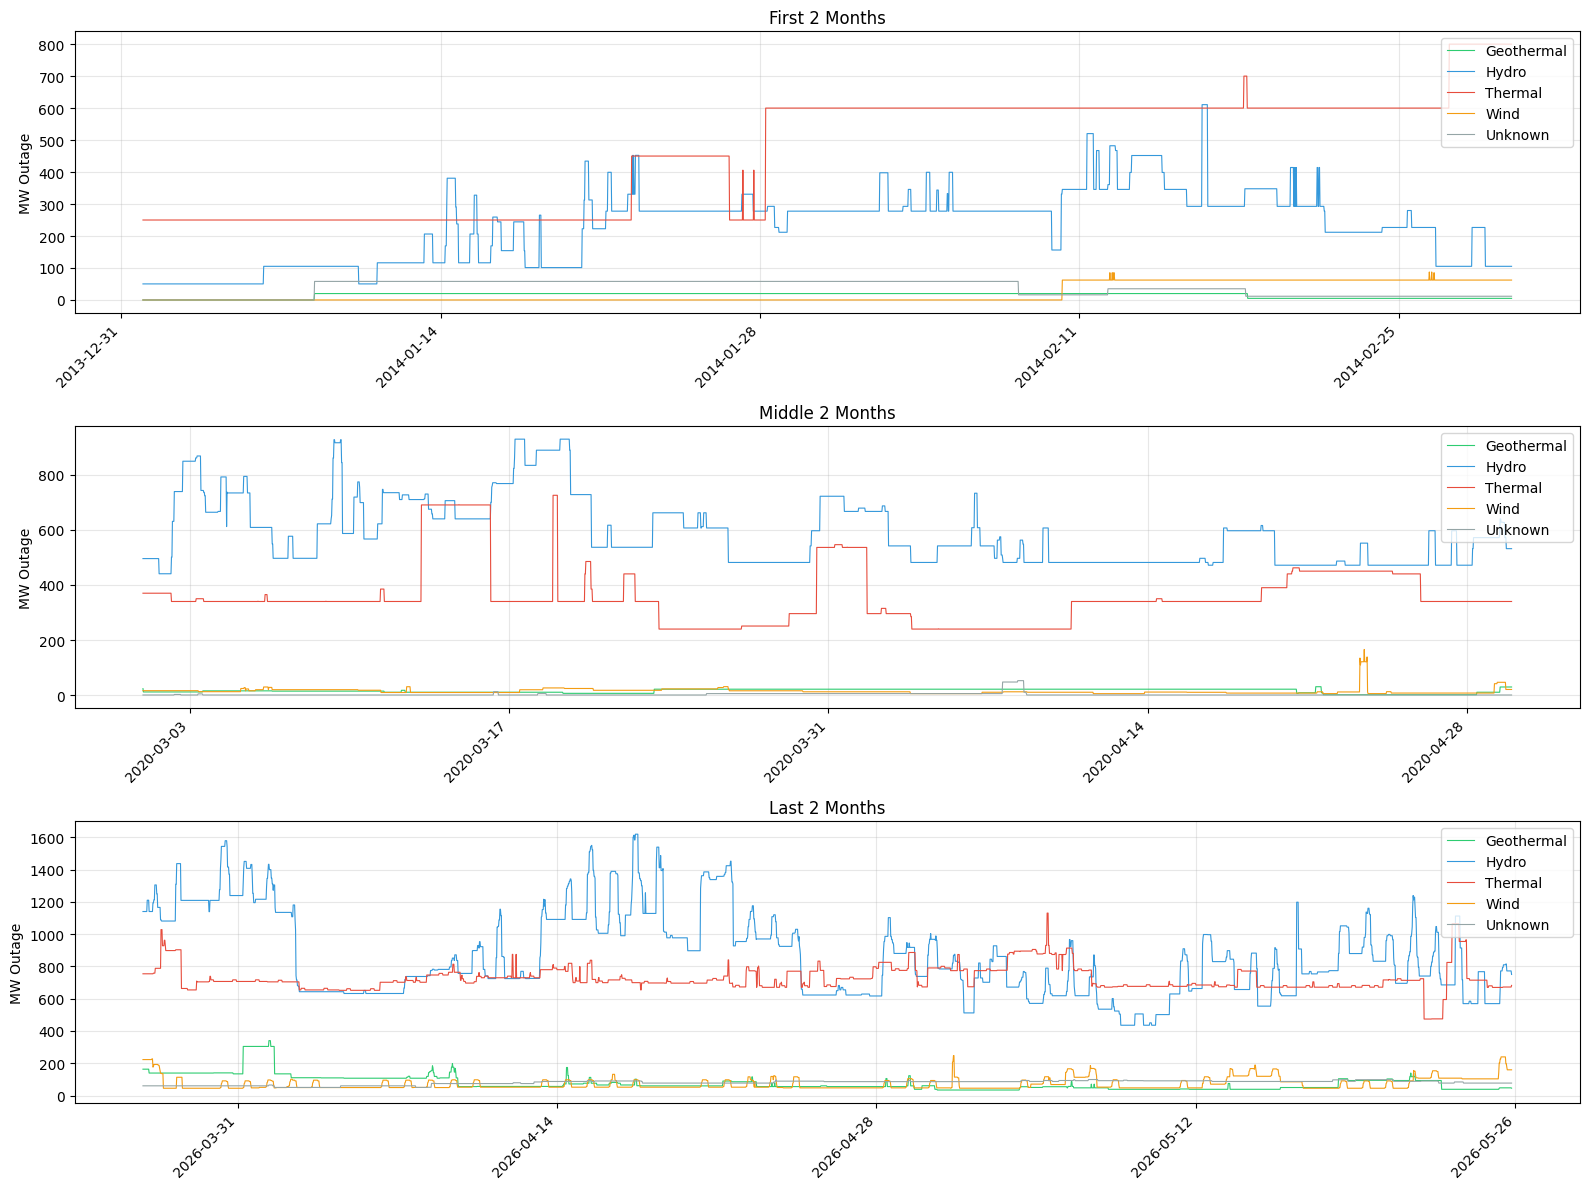

In [14]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_outages(df):
    total_months = (df.index[-1].year - df.index[0].year) * 12 + (df.index[-1].month - df.index[0].month)
    mid_month = df.index[0] + pd.DateOffset(months=total_months // 2)

    slices = {
        'First 2 Months': df.iloc[:2*48*30],
        'Middle 2 Months': df[mid_month: mid_month + pd.DateOffset(months=2)],
        'Last 2 Months': df.iloc[-2*48*30:],
    }

    colors = {'NZ_G': '#2ecc71', 'NZ_H': '#3498db', 'NZ_T': '#e74c3c', 'NZ_W': '#f39c12', 'UNKN': '#95a5a6'}
    labels = {'NZ_G': 'Geothermal', 'NZ_H': 'Hydro', 'NZ_T': 'Thermal', 'NZ_W': 'Wind', 'UNKN': 'Unknown'}

    fig, axes = plt.subplots(3, 1, figsize=(16, 12))

    for ax, (title, data) in zip(axes, slices.items()):
        for col in df.columns:
            ax.plot(data.index, data[col], label=labels[col], color=colors[col], linewidth=0.8)
        ax.set_title(title)
        ax.set_ylabel('MW Outage')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

plot_outages(df_outages)